In [286]:
# Install required packages
%pip install torch torch-geometric scikit-learn matplotlib pandas numpy tqdm -q


Note: you may need to restart the kernel to use updated packages.


# GDN for UNSUPERVISED Anomaly Detection on Car OBD Time Series

This notebook implements a Graph Deviation Network (GDN) for unsupervised anomaly detection on car OBD-II sensor data. The model learns normal sensor relationships and detects anomalies through forecasting reconstruction error.


In [287]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"


In [288]:
columns = ['ENGINE_RUN_TINE ()','ENGINE_RPM ()','VEHICLE_SPEED ()','THROTTLE ()','ENGINE_LOAD ()','COOLANT_TEMPERATURE ()','LONG_TERM_FUEL_TRIM_BANK_1 ()','SHORT_TERM_FUEL_TRIM_BANK_1 ()','INTAKE_MANIFOLD_PRESSURE ()','FUEL_TANK ()','ABSOLUTE_THROTTLE_B ()','PEDAL_D ()','PEDAL_E ()','COMMANDED_THROTTLE_ACTUATOR ()','FUEL_AIR_COMMANDED_EQUIV_RATIO ()','ABSOLUTE_BAROMETRIC_PRESSURE ()','RELATIVE_THROTTLE_POSITION ()','INTAKE_AIR_TEMP ()','TIMING_ADVANCE ()','CATALYST_TEMPERATURE_BANK1_SENSOR1 ()','CATALYST_TEMPERATURE_BANK1_SENSOR2 ()','CONTROL_MODULE_VOLTAGE ()','COMMANDED_EVAPORATIVE_PURGE ()']

# Load OBD dataset - using normal drive data for training
data_dir = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"

# Load multiple drive files to get more normal training data
drive_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
print(f"Found {len(drive_files)} drive files")

# Load and combine multiple drive files
dfs = []
for file in drive_files[:5]:  # Use first 5 drive files for training
    filepath = os.path.join(data_dir, file)
    df = pd.read_csv(filepath)
    dfs.append(df)
    print(f"Loaded {file}: {df.shape}")

# Combine all data
df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

df = df[columns]

# Clean column names (remove trailing spaces and parentheses)

print(f"\nColumns: {list(df.columns)}")
print(f"Final dataset shape: {df.shape}")


Found 129 drive files
Loaded ufpe18.csv: (2271, 27)
Loaded ufpe8.csv: (2671, 27)
Loaded ufpe9.csv: (1895, 27)
Loaded drive13.csv: (4092, 27)
Loaded idle38.csv: (1289, 27)

Combined dataset shape: (12218, 27)

Columns: ['ENGINE_RUN_TINE ()', 'ENGINE_RPM ()', 'VEHICLE_SPEED ()', 'THROTTLE ()', 'ENGINE_LOAD ()', 'COOLANT_TEMPERATURE ()', 'LONG_TERM_FUEL_TRIM_BANK_1 ()', 'SHORT_TERM_FUEL_TRIM_BANK_1 ()', 'INTAKE_MANIFOLD_PRESSURE ()', 'FUEL_TANK ()', 'ABSOLUTE_THROTTLE_B ()', 'PEDAL_D ()', 'PEDAL_E ()', 'COMMANDED_THROTTLE_ACTUATOR ()', 'FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'ABSOLUTE_BAROMETRIC_PRESSURE ()', 'RELATIVE_THROTTLE_POSITION ()', 'INTAKE_AIR_TEMP ()', 'TIMING_ADVANCE ()', 'CATALYST_TEMPERATURE_BANK1_SENSOR1 ()', 'CATALYST_TEMPERATURE_BANK1_SENSOR2 ()', 'CONTROL_MODULE_VOLTAGE ()', 'COMMANDED_EVAPORATIVE_PURGE ()']
Final dataset shape: (12218, 23)


In [289]:
# Select key OBD sensor features
# Using all numeric columns (27 sensors from OBD-II)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_cols].copy()
print(f"✓ Numeric columns: {len(numeric_cols)}")

# Step 1: Remove columns that are ALL NaN or constant
def clean_columns(df):
    """Remove useless columns"""
    # Drop columns with >95% missing
    missing_pct = df.isnull().sum() / len(df)
    cols_to_keep = missing_pct[missing_pct < 0.95].index.tolist()
    df = df[cols_to_keep]
    print(f"✓ Removed {len(missing_pct) - len(cols_to_keep)} columns with >95% missing")
    
    # Drop constant columns (std = 0)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    std_vals = df[numeric_cols].std()
    non_constant = std_vals[std_vals > 1e-6].index.tolist()
    df = df[non_constant]
    print(f"✓ Removed {len(numeric_cols) - len(non_constant)} constant columns")
    
    return df

df_cleaned = clean_columns(df_numeric)
print(f"After column filtering: {df_cleaned.shape}")

# Step 2: Handle remaining missing values (IMPUTE, don't drop!)
print(f"\n🔍 Missing values per column:")
missing_summary = df_cleaned.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    print(missing_summary.head(10))
    print(f"   ... ({len(missing_summary)} columns with missing values)")
else:
    print("   None!")

# Strategy: Forward fill -> Backward fill -> Fill with column median
df_imputed = df_cleaned.copy()
df_imputed = df_imputed.fillna(method='ffill')  # Forward fill (time series)
df_imputed = df_imputed.fillna(method='bfill')  # Backward fill
df_imputed = df_imputed.fillna(df_imputed.median())  # Fill any remaining with median

print(f"✓ After imputation: {df_imputed.shape}")
print(f"✓ Remaining NaN: {df_imputed.isnull().sum().sum()}")

# Final clean dataset
df_clean = df_imputed
feature_cols = df_clean.columns.tolist()

print(f"\n✅ Final dataset ready:")
print(f"   Shape: {df_clean.shape}")
print(f"   Sensors: {len(feature_cols)}")
print(f"   Missing: {df_clean.isnull().sum().sum()}")
print(f"\nFeatures: {feature_cols[:10]}...")  # Show first 10


✓ Numeric columns: 23
✓ Removed 0 columns with >95% missing
✓ Removed 2 constant columns
After column filtering: (12218, 21)

🔍 Missing values per column:
   None!
✓ After imputation: (12218, 21)
✓ Remaining NaN: 0

✅ Final dataset ready:
   Shape: (12218, 21)
   Sensors: 21
   Missing: 0

Features: ['ENGINE_RUN_TINE ()', 'ENGINE_RPM ()', 'VEHICLE_SPEED ()', 'THROTTLE ()', 'ENGINE_LOAD ()', 'COOLANT_TEMPERATURE ()', 'LONG_TERM_FUEL_TRIM_BANK_1 ()', 'SHORT_TERM_FUEL_TRIM_BANK_1 ()', 'INTAKE_MANIFOLD_PRESSURE ()', 'FUEL_TANK ()']...


In [290]:
# Data Preprocessing: Create windows, train/test split, scaling
from sklearn.model_selection import train_test_split

window_size = 10  # Look back 10 timesteps
stride = 1  # Sliding window with stride 1

def create_windows(data, window_size, stride=1):
    """Create sliding windows from time series"""
    windows = []
    for i in range(0, len(data) - window_size + 1, stride):
        windows.append(data[i:i+window_size])
    return np.array(windows)

# Extract feature values
X = df_clean[feature_cols].values
print(f"Original data shape: {X.shape}")

# Create windows
X_windows = create_windows(X, window_size, stride)
print(f"Windows shape: {X_windows.shape}  # [num_windows, window_size, num_features]")

# Train/test split (80/20)
split_idx = int(0.8 * len(X_windows))
X_train_windows = X_windows[:split_idx]
X_test_windows = X_windows[split_idx:]

print(f"Train windows: {X_train_windows.shape}")
print(f"Test windows: {X_test_windows.shape}")

# Scale data (fit on training, transform both)
scaler = StandardScaler()
# Reshape for scaling: [num_windows * window_size, num_features]
X_train_flat = X_train_windows.reshape(-1, X_train_windows.shape[-1])
X_test_flat = X_test_windows.reshape(-1, X_test_windows.shape[-1])

scaler.fit(X_train_flat)
X_train_scaled_flat = scaler.transform(X_train_flat)
X_test_scaled_flat = scaler.transform(X_test_flat)

# Reshape back to windows
X_train_scaled = X_train_scaled_flat.reshape(X_train_windows.shape)
X_test_scaled = X_test_scaled_flat.reshape(X_test_windows.shape)

print(f"\n✓ Data preprocessing complete!")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Test: {X_test_scaled.shape}")
print(f"  Features: {len(feature_cols)} sensors")


Original data shape: (12218, 21)
Windows shape: (12209, 10, 21)  # [num_windows, window_size, num_features]
Train windows: (9767, 10, 21)
Test windows: (2442, 10, 21)

✓ Data preprocessing complete!
  Train: (9767, 10, 21)
  Test: (2442, 10, 21)
  Features: 21 sensors


In [291]:
# SIMPLEST SOLUTION - Manual batching
from torch.utils.data import Dataset, DataLoader as TorchDataLoader

class SimpleOBDDataset(Dataset):
    def __init__(self, X_windows):
        self.X = torch.FloatTensor(X_windows)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        window = self.X[idx]
        x = window[-1, :]  # Last timestep [num_sensors]
        return x, x  # Input and target (same for reconstruction)


In [292]:
# SIMPLIFIED GDN using standard GATConv
class GDN_Fixed(nn.Module):
    def __init__(self, num_sensors, hidden_dim=64, heads=4):
        super().__init__()
        self.num_sensors = num_sensors
        self.hidden_dim = hidden_dim
        
        # Learnable sensor embeddings
        self.sensor_embeds = nn.Parameter(torch.randn(num_sensors, hidden_dim))
        
        # Standard GAT layers (no custom messaging)
        self.gat1 = GATConv(1, hidden_dim, heads=heads, concat=False)
        self.gat2 = GATConv(hidden_dim, hidden_dim, heads=heads, concat=False)
        
        # Forecasting head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_sensors)
        )
        
        # Build fully connected graph (learns attention weights)
        edge_list = []
        for i in range(num_sensors):
            for j in range(num_sensors):
                if i != j:
                    edge_list.append([i, j])
        self.register_buffer('edge_index', torch.tensor(edge_list, dtype=torch.long).t())
    
    def forward(self, x_batch):
        """
        x_batch: [batch_size, num_sensors] - current sensor readings
        Returns: [batch_size, num_sensors] - forecasted readings
        """
        batch_size = x_batch.shape[0]
        
        # Expand node features for batched processing
        # [batch_size, num_sensors] -> [batch_size*num_sensors, 1]
        x_nodes = x_batch.view(-1, 1)
        
        # Create batch indices
        batch_idx = torch.arange(batch_size, device=x_batch.device).repeat_interleave(self.num_sensors)
        
        # Expand edge_index for batch
        edge_index_list = []
        for b in range(batch_size):
            offset = b * self.num_sensors
            edge_index_list.append(self.edge_index + offset)
        edge_index_batch = torch.cat(edge_index_list, dim=1)
        
        # Graph propagation
        h = F.relu(self.gat1(x_nodes, edge_index_batch))
        h = F.dropout(h, 0.2, training=self.training)
        h = self.gat2(h, edge_index_batch)
        
        # Reshape to [batch_size, num_sensors, hidden_dim]
        h = h.view(batch_size, self.num_sensors, self.hidden_dim)
        
        # Element-wise multiply with embeddings
        h = h * self.sensor_embeds.unsqueeze(0)
        
        # Pool across sensors
        h_pooled = h.mean(dim=1)  # [batch_size, hidden_dim]
        
        # Forecast
        out = self.fc(h_pooled)
        
        return out


In [293]:
# Simple dataset (already defined in cell 6, but keeping for reference)
# SimpleOBDDataset is defined in cell 6


In [294]:
# Create dataloaders
train_dataset = SimpleOBDDataset(X_train_scaled)
test_dataset = SimpleOBDDataset(X_test_scaled)

train_loader = TorchDataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
test_loader = TorchDataLoader(test_dataset, batch_size=128, shuffle=False)

# Initialize model
num_sensors = X_train_scaled.shape[-1]
model = GDN_Fixed(num_sensors=num_sensors, hidden_dim=128, heads=4).to(device)

print(f"🔧 GDN Model (FIXED):")
print(f"  Sensors: {num_sensors}")
print(f"  Hidden: 128, Heads: 4")
print(f"  Edges: {model.edge_index.shape[1]} (fully connected)")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test it
x_test, y_test = next(iter(train_loader))
x_test = x_test.to(device)
pred_test = model(x_test)
print(f"\n✓ Batch shapes:")
print(f"  x: {x_test.shape}")
print(f"  y: {y_test.shape}")
print(f"  Forecast shape: {pred_test.shape}")


🔧 GDN Model (FIXED):
  Sensors: 21
  Hidden: 128, Heads: 4
  Edges: 420 (fully connected)
  Parameters: 90,261

✓ Batch shapes:
  x: torch.Size([128, 21])
  y: torch.Size([128, 21])
  Forecast shape: torch.Size([128, 21])


In [295]:
# Training function
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    
    for x_batch, y_batch in tqdm(loader, desc="Train", leave=False):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = F.mse_loss(pred, y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item() * x_batch.shape[0]
    
    return total_loss / len(loader.dataset)


In [296]:
# Train with better settings
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

epochs = 100
train_losses = []
best_loss = float('inf')

print("\n🚀 Training GDN (FIXED)...")
print("="*60)

for epoch in range(epochs):
    loss = train_epoch(model, train_loader, optimizer)
    train_losses.append(loss)
    scheduler.step()
    
    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), 'best_gdn_obd.pt')
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}: Loss={loss:.6f}, Best={best_loss:.6f}")

print("="*60)
print(f"✅ Training complete! Best: {best_loss:.6f}")

model.load_state_dict(torch.load('best_gdn_obd.pt'))

# Quick validation
model.eval()
with torch.no_grad():
    x_test, y_test = next(iter(test_loader))
    x_test = x_test[:5].to(device)
    y_test = y_test[:5].cpu().numpy()
    pred = model(x_test).cpu().numpy()
    
    print("\n🔍 Sample predictions:")
    print(f"True:  {y_test[0, :5]}")
    print(f"Pred:  {pred[0, :5]}")
    corr = np.corrcoef(y_test.flatten(), pred.flatten())[0, 1]
    print(f"Correlation: {corr:.4f}")



🚀 Training GDN (FIXED)...


Epoch   0: Loss=0.986165, Best=0.986165


Epoch  10: Loss=0.621076, Best=0.621076


Epoch  20: Loss=0.562262, Best=0.562262


Epoch  30: Loss=0.550073, Best=0.549922


...

Epoch  60: Loss=0.534706, Best=0.534528


Epoch  70: Loss=0.533116, Best=0.532927


Epoch  80: Loss=0.532653, Best=0.531884


Epoch  90: Loss=0.531590, Best=0.530900


✅ Training complete! Best: 0.530657

🔍 Sample predictions:
True:  [-0.84665495 -0.7632629  -0.09829961  0.14749785  0.44130632]
Pred:  [-0.21246561 -0.16914831 -0.22996278 -0.21079245  0.29855865]
Correlation: 0.8542


In [297]:
# ANOMALY INJECTION
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

def inject_multivariate_anomalies(X, feature_cols, anomaly_ratio=0.12, seed=42):
    """Inject realistic automotive anomalies"""
    np.random.seed(seed)
    num_windows = X.shape[0]
    num_sensors = X.shape[2]
    window_size = X.shape[1]
    
    labels = np.zeros(num_windows, dtype=int)
    n_anomalies = int(num_windows * anomaly_ratio)
    anomaly_indices = np.random.choice(num_windows, n_anomalies, replace=False)
    labels[anomaly_indices] = 1
    
    X_injected = X.copy()
    
    for idx in anomaly_indices:
        anom_type = np.random.choice(['spike', 'shift', 'pattern'], p=[0.3, 0.3, 0.4])
        n_affected = np.random.randint(1, min(4, num_sensors + 1))
        affected_sensors = np.random.choice(num_sensors, n_affected, replace=False)
        
        if anom_type == 'spike':
            # Point anomalies (sensor glitch)
            for sensor in affected_sensors:
                timesteps = np.random.choice(window_size, np.random.randint(1, 4), replace=False)
                magnitude = np.random.uniform(3, 6) * np.random.choice([-1, 1])
                X_injected[idx, timesteps, sensor] += magnitude
        
        elif anom_type == 'shift':
            # Level shift (bias/drift)
            for sensor in affected_sensors:
                offset = np.random.uniform(2, 4) * np.random.choice([-1, 1])
                X_injected[idx, :, sensor] += offset
        
        elif anom_type == 'pattern':
            # Break correlation (contextual anomaly)
            if num_sensors >= 2:
                sensor_a, sensor_b = np.random.choice(num_sensors, 2, replace=False)
                factor = np.random.uniform(1.5, 2.5)
                X_injected[idx, :, sensor_a] *= factor
    
    print(f"💉 Injected {n_anomalies} anomalies ({100*anomaly_ratio:.1f}%)")
    print(f"   Spikes: {int(n_anomalies*0.3)}, Shifts: {int(n_anomalies*0.3)}, Patterns: {int(n_anomalies*0.4)}")
    
    return X_injected, labels

# Inject anomalies into test set
X_test_anomalous, y_test_labels = inject_multivariate_anomalies(
    X_test_scaled, 
    feature_cols, 
    anomaly_ratio=0.12,  # 12% like SWaT
    seed=42
)

print(f"\n📊 Test set composition:")
print(f"   Normal: {np.sum(y_test_labels == 0):,} ({100*np.mean(y_test_labels == 0):.1f}%)")
print(f"   Anomaly: {np.sum(y_test_labels == 1):,} ({100*np.mean(y_test_labels == 1):.1f}%)")


💉 Injected 293 anomalies (12.0%)
   Spikes: 87, Shifts: 87, Patterns: 117

📊 Test set composition:
   Normal: 2,149 (88.0%)
   Anomaly: 293 (12.0%)


In [298]:
# Create test loader with anomalies
test_dataset_anom = SimpleOBDDataset(X_test_anomalous)
test_loader_anom = TorchDataLoader(test_dataset_anom, batch_size=128, shuffle=False)


In [299]:
# ANOMALY DETECTION & F1 EVALUATION
def evaluate_with_f1(model, loader, true_labels, threshold_percentile=95):
    model.eval()
    all_scores = []
    
    with torch.no_grad():
        for x_batch, y_batch in tqdm(loader, desc="Detecting", leave=False):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            forecast = model(x_batch)
            target = y_batch
            
            # Per-sensor error (eq 11)
            sensor_errors = torch.abs(forecast - target).cpu()
            
            # Robust normalization (eq 12)
            for s in range(sensor_errors.shape[-1]):
                err = sensor_errors[:, s]
                median = torch.median(err)
                q25, q75 = torch.quantile(err, 0.25), torch.quantile(err, 0.75)
                iqr = q75 - q25
                if iqr > 1e-6:
                    sensor_errors[:, s] = (err - median) / iqr
            
            # Max over sensors (eq 13)
            scores = torch.max(sensor_errors, dim=1)[0].numpy()
            all_scores.extend(scores)
    
    all_scores = np.array(all_scores)
    threshold = np.percentile(all_scores, threshold_percentile)
    predictions = (all_scores > threshold).astype(int)
    
    precision = precision_score(true_labels, predictions, zero_division=0)
    recall = recall_score(true_labels, predictions, zero_division=0)
    f1 = f1_score(true_labels, predictions, zero_division=0)
    
    return {
        'scores': all_scores,
        'predictions': predictions,
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Evaluate!
results = evaluate_with_f1(model, test_loader_anom, y_test_labels, threshold_percentile=95)

print("\n" + "="*60)
print("🎯 ANOMALY DETECTION RESULTS")
print("="*60)
print(f"Threshold:  {results['threshold']:.4f}")
print(f"Precision:  {results['precision']:.4f}")
print(f"Recall:     {results['recall']:.4f}")
print(f"F1 Score:   {results['f1']:.4f}")
print("="*60)

print("\n📋 Classification Report:")
print(classification_report(y_test_labels, results['predictions'], 
                          target_names=['Normal', 'Anomaly'], digits=4))

cm = confusion_matrix(y_test_labels, results['predictions'])
print("\n📊 Confusion Matrix:")
print(f"                Predicted")
print(f"              Normal  Anomaly")
print(f"True Normal     {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"     Anomaly    {cm[1,0]:4d}    {cm[1,1]:4d}")



🎯 ANOMALY DETECTION RESULTS
Threshold:  15.1959
Precision:  0.8130
Recall:     0.3413
F1 Score:   0.4808

📋 Classification Report:
              precision    recall  f1-score   support

      Normal     0.9168    0.9893    0.9517      2149
     Anomaly     0.8130    0.3413    0.4808       293

    accuracy                         0.9115      2442
   macro avg     0.8649    0.6653    0.7162      2442
weighted avg     0.9043    0.9115    0.8952      2442


📊 Confusion Matrix:
                Predicted
              Normal  Anomaly
True Normal     2126      23
     Anomaly     193     100


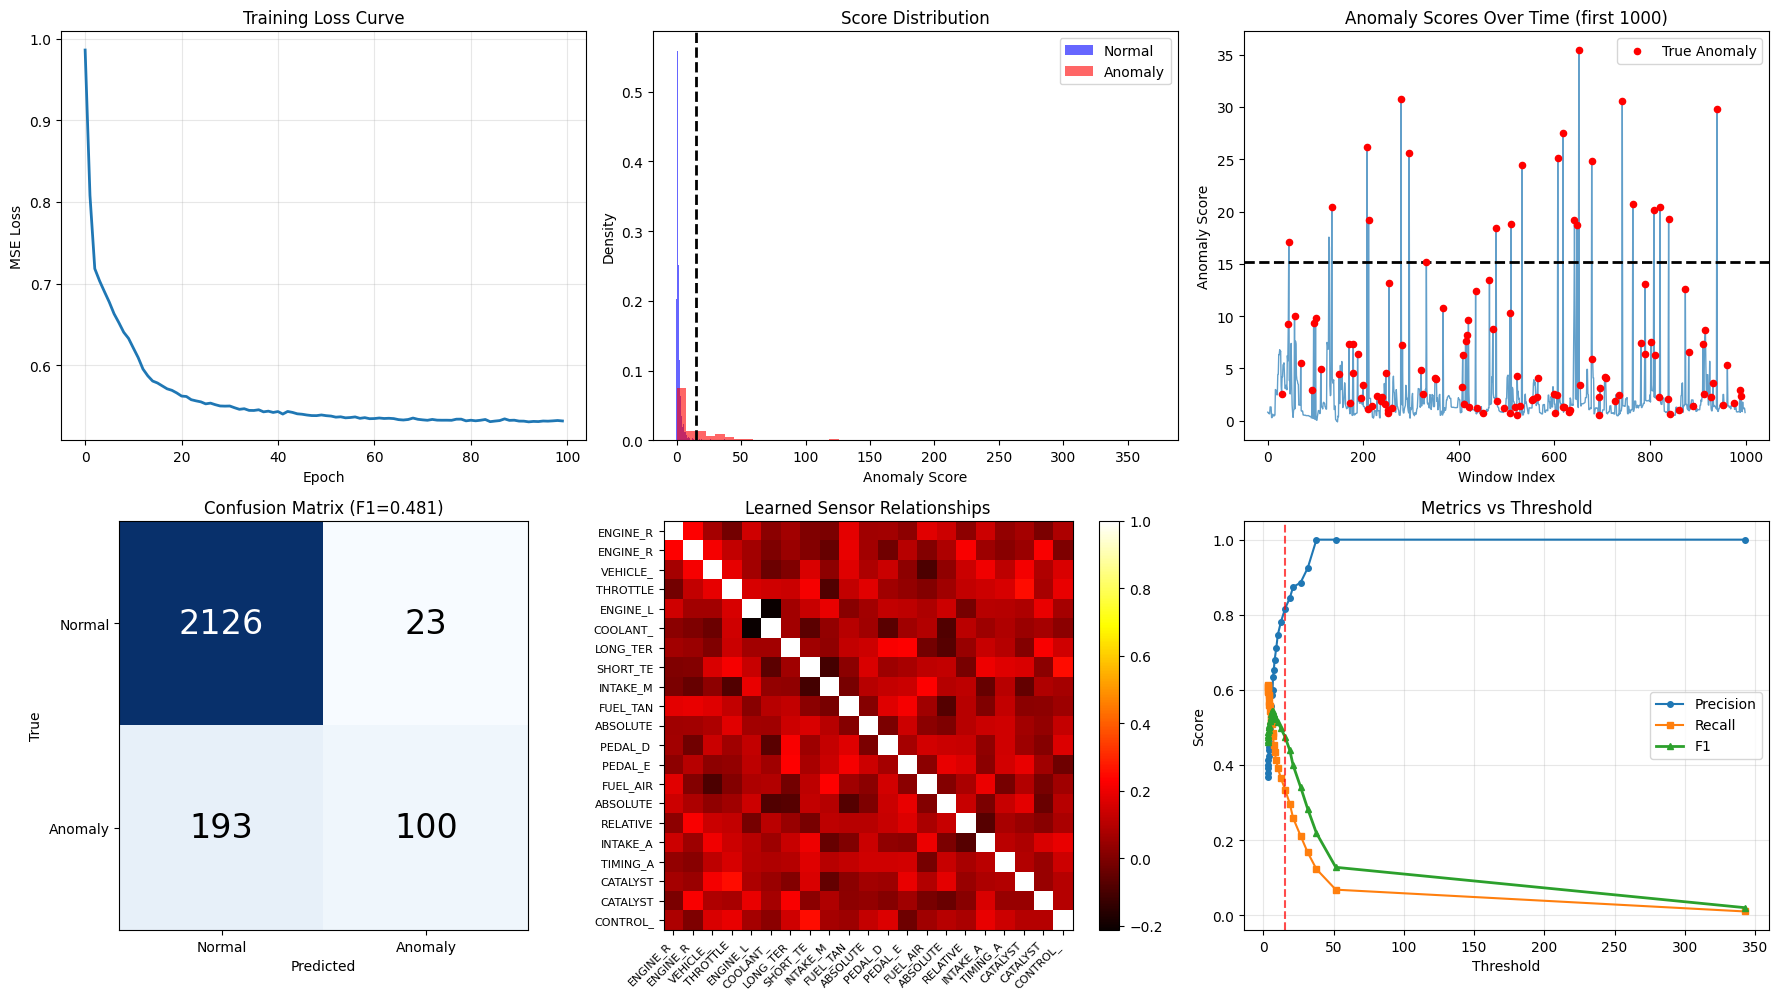


✅ Training and evaluation complete!
📁 Model saved: best_gdn_obd.pt
📁 Results plot: gdn_final_results.png


In [300]:
# VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Training loss
axes[0, 0].plot(train_losses, linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training Loss Curve')
axes[0, 0].grid(alpha=0.3)

# 2. Score distribution
axes[0, 1].hist(results['scores'][y_test_labels == 0], bins=50, alpha=0.6, 
                label='Normal', color='blue', density=True)
axes[0, 1].hist(results['scores'][y_test_labels == 1], bins=50, alpha=0.6, 
                label='Anomaly', color='red', density=True)
axes[0, 1].axvline(results['threshold'], color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Anomaly Score')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Score Distribution')
axes[0, 1].legend()

# 3. Time series
n_show = min(1000, len(results['scores']))
axes[0, 2].plot(results['scores'][:n_show], alpha=0.7, linewidth=1)
axes[0, 2].scatter([i for i in range(n_show) if y_test_labels[i] == 1],
                   [results['scores'][i] for i in range(n_show) if y_test_labels[i] == 1],
                   color='red', s=20, label='True Anomaly', zorder=5)
axes[0, 2].axhline(results['threshold'], color='black', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Window Index')
axes[0, 2].set_ylabel('Anomaly Score')
axes[0, 2].set_title(f'Anomaly Scores Over Time (first {n_show})')
axes[0, 2].legend()

# 4. Confusion matrix
im = axes[1, 0].imshow(cm, cmap='Blues', interpolation='nearest')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Normal', 'Anomaly'])
axes[1, 0].set_yticklabels(['Normal', 'Anomaly'])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')
axes[1, 0].set_title(f'Confusion Matrix (F1={results["f1"]:.3f})')
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm[i, j]), ha='center', va='center', 
                       fontsize=24, color='white' if cm[i, j] > cm.max()/2 else 'black')

# 5. Learned sensor graph
sim = F.normalize(model.sensor_embeds, p=2, dim=1)
sim = torch.mm(sim, sim.t()).detach().cpu().numpy()
im = axes[1, 1].imshow(sim, cmap='hot', interpolation='nearest')
axes[1, 1].set_xticks(range(num_sensors))
axes[1, 1].set_yticks(range(num_sensors))
axes[1, 1].set_xticklabels([f[:8] for f in feature_cols], rotation=45, ha='right', fontsize=8)
axes[1, 1].set_yticklabels([f[:8] for f in feature_cols], fontsize=8)
axes[1, 1].set_title('Learned Sensor Relationships')
plt.colorbar(im, ax=axes[1, 1])

# 6. Precision-Recall vs Threshold
thresholds = np.percentile(results['scores'], np.linspace(80, 99.9, 30))
precs, recs, f1s = [], [], []
for thresh in thresholds:
    preds = (results['scores'] > thresh).astype(int)
    precs.append(precision_score(y_test_labels, preds, zero_division=0))
    recs.append(recall_score(y_test_labels, preds, zero_division=0))
    f1s.append(f1_score(y_test_labels, preds, zero_division=0))

axes[1, 2].plot(thresholds, precs, label='Precision', marker='o', markersize=4)
axes[1, 2].plot(thresholds, recs, label='Recall', marker='s', markersize=4)
axes[1, 2].plot(thresholds, f1s, label='F1', marker='^', linewidth=2, markersize=4)
axes[1, 2].axvline(results['threshold'], color='red', linestyle='--', alpha=0.7)
axes[1, 2].set_xlabel('Threshold')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Metrics vs Threshold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Training and evaluation complete!")
print(f"📁 Model saved: best_gdn_obd.pt")
print(f"📁 Results plot: gdn_final_results.png")


In [301]:
# Top sensor relationships (interpretability)
print("\nTop Learned Sensor Dependencies:")
sim_matrix = F.normalize(model.sensor_embeds, p=2, dim=1)
sim_matrix = torch.mm(sim_matrix, sim_matrix.t()).detach().cpu().numpy()
np.fill_diagonal(sim_matrix, -1)

# Get top pairs
top_pairs = []
for i in range(len(sim_matrix)):
    for j in range(i+1, len(sim_matrix)):
        top_pairs.append((i, j, sim_matrix[i, j]))

top_pairs.sort(key=lambda x: x[2], reverse=True)

print(f"\nTop 15 Sensor Relationships:")
for idx, (sensor1, sensor2, sim_val) in enumerate(top_pairs[:15]):
    sensor1_name = feature_cols[sensor1][:30] if sensor1 < len(feature_cols) else f"Sensor_{sensor1}"
    sensor2_name = feature_cols[sensor2][:30] if sensor2 < len(feature_cols) else f"Sensor_{sensor2}"
    print(f"{idx+1:2d}. {sensor1_name:30s} <-> {sensor2_name:30s}: {sim_val:.3f}")



Top Learned Sensor Dependencies:

Top 15 Sensor Relationships:
 1. THROTTLE ()                    <-> CATALYST_TEMPERATURE_BANK1_SEN: 0.254
 2. SHORT_TERM_FUEL_TRIM_BANK_1 () <-> CONTROL_MODULE_VOLTAGE ()     : 0.252
 3. INTAKE_MANIFOLD_PRESSURE ()    <-> FUEL_AIR_COMMANDED_EQUIV_RATIO: 0.232
 4. LONG_TERM_FUEL_TRIM_BANK_1 ()  <-> PEDAL_E ()                    : 0.231
 5. ENGINE_RUN_TINE ()             <-> ENGINE_RPM ()                 : 0.230
 6. LONG_TERM_FUEL_TRIM_BANK_1 ()  <-> PEDAL_D ()                    : 0.223
 7. ENGINE_RPM ()                  <-> RELATIVE_THROTTLE_POSITION () : 0.222
 8. LONG_TERM_FUEL_TRIM_BANK_1 ()  <-> CATALYST_TEMPERATURE_BANK1_SEN: 0.222
 9. ENGINE_RPM ()                  <-> CATALYST_TEMPERATURE_BANK1_SEN: 0.221
10. THROTTLE ()                    <-> SHORT_TERM_FUEL_TRIM_BANK_1 (): 0.217
11. FUEL_TANK ()                   <-> PEDAL_E ()                    : 0.216
12. ENGINE_RPM ()                  <-> VEHICLE_SPEED ()              : 0.214
13. VEHICLE_

In [302]:
# Save anomaly scores for further analysis
anomaly_results = pd.DataFrame({
    'timestep': range(len(results['scores'])),
    'anomaly_score': results['scores'],
    'predicted_anomaly': results['predictions'],
    'true_anomaly': y_test_labels
})

print(f"Summary statistics:")
print(anomaly_results.describe())


Summary statistics:
          timestep  anomaly_score  predicted_anomaly  true_anomaly
count  2442.000000    2442.000000        2442.000000   2442.000000
mean   1220.500000       4.394384           0.050369      0.119984
std     705.089001      18.624037           0.218749      0.325009
min       0.000000      -0.105985           0.000000      0.000000
25%     610.250000       0.828683           0.000000      0.000000
50%    1220.500000       1.328218           0.000000      0.000000
75%    1830.750000       2.479513           0.000000      0.000000
max    2441.000000     370.039185           1.000000      1.000000
